# Validation : la matrice de contagion VAR a-t-elle du sens ?

146 actions US, log-returns 30 min, 2019-04 → 2023-05 (T = 13 360, mean |ρ| = 0.38).
On veut une **matrice de contagion** crédible — pas un prédicteur. Donc l'OOS R²
n'est pas le bon test (le VAR n'a aucune raison d'extrapoler entre régimes).

Tests retenus, tous *in-sample*, comparés à trois benchmarks de null. **Le rôle
de chaque null est crucial** :

| Null | Préserve | Casse | Ce qu'il teste |
|---|---|---|---|
| **Gaussien i.i.d.** | vol par actif | autocorr + cross-corr | baseline absolue |
| **Phase-randomized** (Theiler 1992, Algo. 1) | spectre de puissance ⇒ autocorr | distribution marginale + cross-corr | est-ce que l'autocorr seule suffit ? |
| **Block bootstrap** | corrélations contemporaines | dynamique temporelle | est-ce que la matrice ne fait que recoder de la corr contemporaine ? |

Le block-bootstrap est le **null le plus instructif** : si la matrice VAR sur
block-boot ressemble à la matrice sur real, alors les coefs lagged ne capturent
pas vraiment de dynamique — juste de la cross-corrélation contemporaine déguisée.

Pas de masque de corrélation (double-dipping). Full VAR(p), OLS.

## 1. Setup et chargement

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import grangercausalitytests
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

from functions import load_data

%matplotlib inline
%config InlineBackend.figure_format='retina'

rng = np.random.default_rng(42)


def fit_subset_var(data, lags):
    """Fit subset VAR : r_t = c + sum_{k in lags} A_k · r_{t-k} + eps.

    Parameters
    ----------
    data : DataFrame ou ndarray, shape (T, N)
    lags : list[int]
        Lags inclus, ex. [1] pour VAR(1), [13] pour subset {13}, [1, 13] pour {1, 13}.

    Returns
    -------
    A_blocks : dict {lag: ndarray (N, N)}
        entree (i, j) = effet de asset_i.L_lag sur asset_j.
    resid : ndarray, shape (T - max(lags), N)
    Sigma : ndarray, shape (N, N)
        Covariance des résidus.
    Y : ndarray, shape (T - max(lags), N)
        Cible alignée.
    B : ndarray, shape (1 + len(lags)*N, N)
        Coefficients complets, ligne 0 = constante.
    """
    arr = data.values if hasattr(data, 'values') else data
    T_, N_ = arr.shape
    p_max = max(lags)
    n = T_ - p_max
    X = np.empty((n, len(lags) * N_ + 1))
    X[:, 0] = 1.0
    for i, k in enumerate(lags):
        X[:, 1 + i * N_ : 1 + (i + 1) * N_] = arr[p_max - k : T_ - k]
    Y = arr[p_max:]
    B, *_ = np.linalg.lstsq(X, Y, rcond=None)
    resid = Y - X @ B
    Sigma = resid.T @ resid / max(n - X.shape[1], 1)
    A_blocks = {k: B[1 + i * N_ : 1 + (i + 1) * N_] for i, k in enumerate(lags)}
    return A_blocks, resid, Sigma, Y, B

In [28]:
real = load_data(['stock'], log_returns=True, sort_by_sector=True)
asset_names = real.columns.tolist()
N = len(asset_names)
T = len(real)

sectors_df = pd.read_excel('data/stock_category.xlsx')
sector_map = sectors_df.set_index('Stocks')['Sectors'].to_dict()
sector_arr = np.array([sector_map.get(a, 'autre') for a in asset_names])

print(f'Actifs   : {N}')
print(f'Obs.     : {T}')
print(f'Periode  : {real.index[0].date()} -> {real.index[-1].date()}')
print(f'Mean |rho| off-diag : {np.abs(np.corrcoef(real.values.T)[np.triu_indices(N, 1)]).mean():.3f}')
print(f'Secteurs : {len(set(sector_arr))}')

Actifs   : 146
Obs.     : 13360
Periode  : 2019-04-01 -> 2023-05-03
Mean |rho| off-diag : 0.384
Secteurs : 10


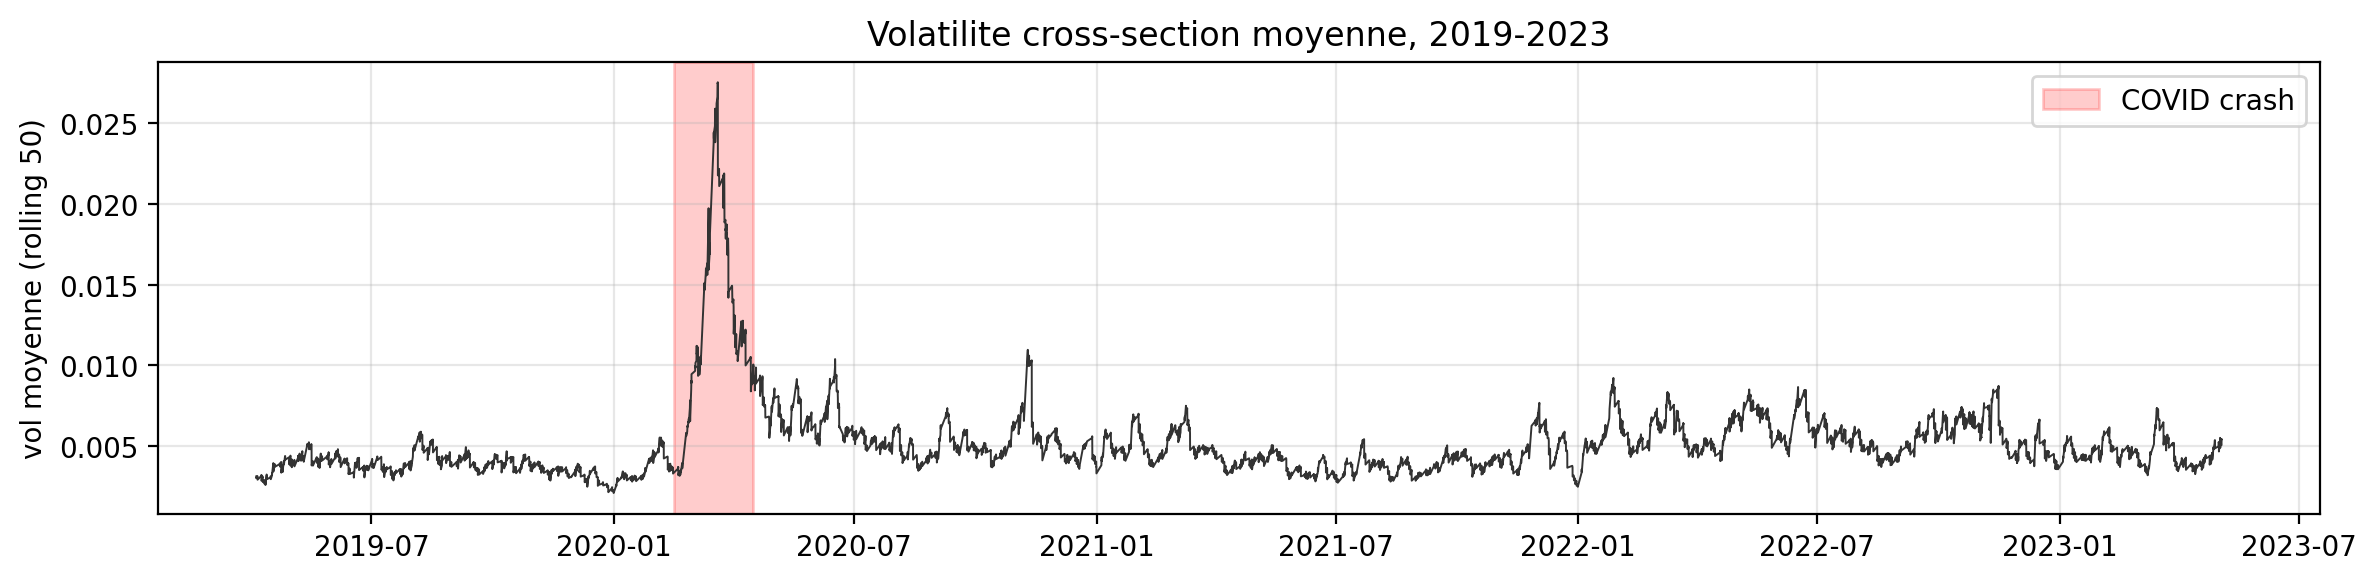

In [29]:
fig, ax = plt.subplots(figsize=(12, 3))
rolling_vol = real.rolling(50).std().mean(axis=1)
ax.plot(rolling_vol.index, rolling_vol.values, lw=0.7, color='#333')
ax.axvspan('2020-02-15', '2020-04-15', alpha=0.2, color='red', label='COVID crash')
ax.set_ylabel('vol moyenne (rolling 50)')
ax.set_title('Volatilite cross-section moyenne, 2019-2023')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

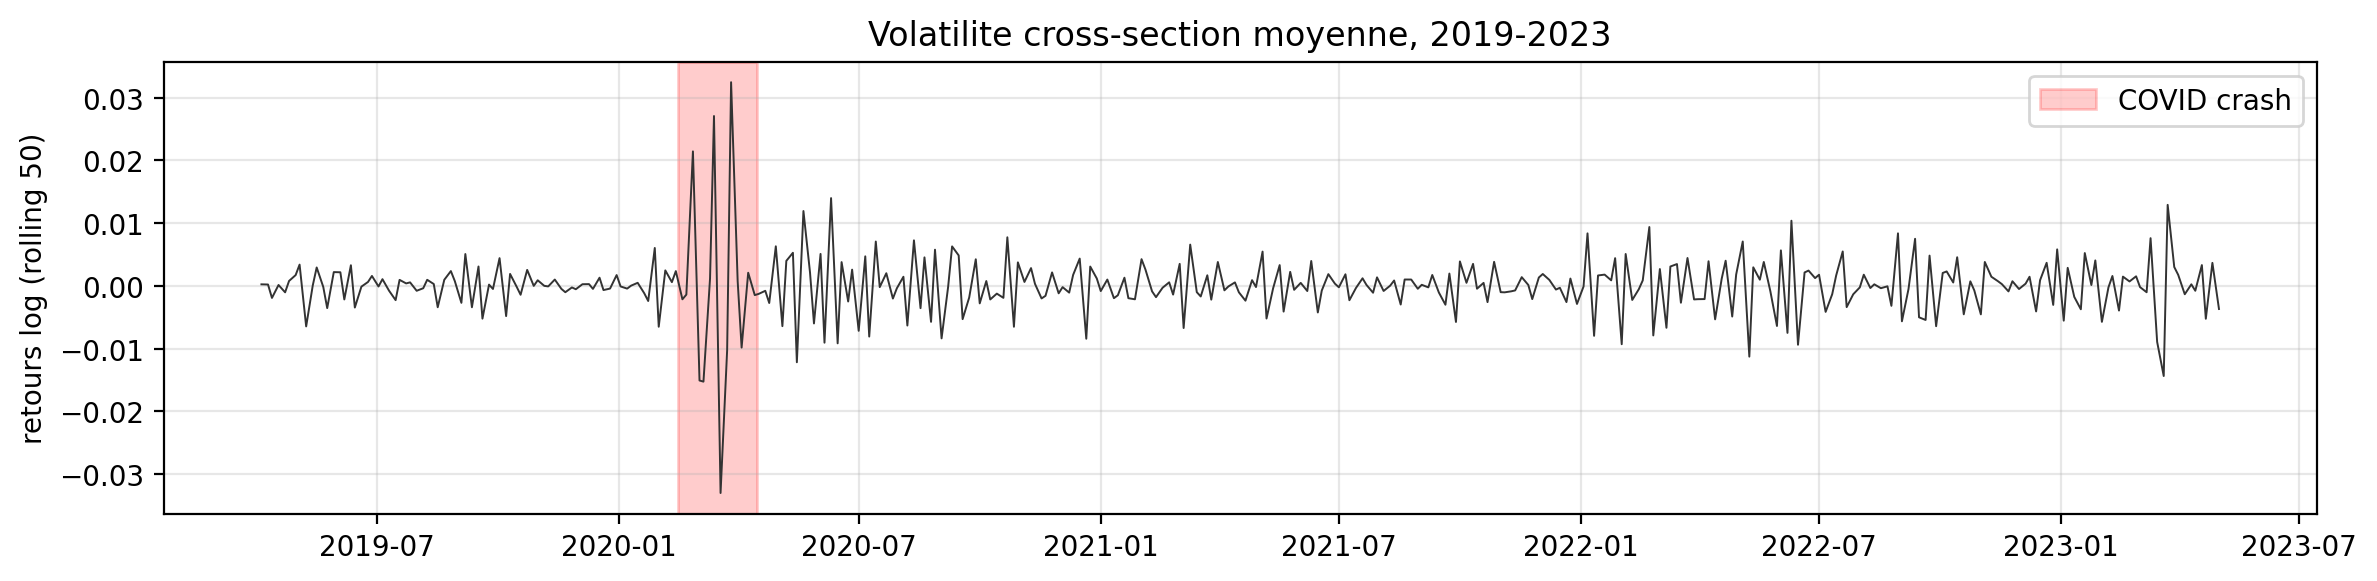

In [30]:
fig, ax = plt.subplots(figsize=(12, 3))
log_returns = real.resample('3B').last().diff().dropna().mean(axis=1)
ax.plot(log_returns.index, log_returns, lw=0.7, color='#333')
ax.axvspan('2020-02-15', '2020-04-15', alpha=0.2, color='red', label='COVID crash')
ax.set_ylabel('retours log (rolling 50)')
ax.set_title('Volatilite cross-section moyenne, 2019-2023')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 2. Trois benchmarks de null

Chacun isole un type de structure. Une *vraie* matrice de contagion doit être
différente des trois.

In [31]:
def gen_iid_gaussian(real, rng):
    """Bruit gaussien independant, calibre sur la vol par actif."""
    sigmas = real.std(axis=0).values
    arr = rng.standard_normal(real.shape) * sigmas
    return pd.DataFrame(arr, index=real.index, columns=real.columns)


def gen_phase_randomized(real, rng):
    """Surrogate phase-randomized (Theiler et al. 1992, Algorithme 1 / FT).

    FFT colonne par colonne, on garde les amplitudes (donc spectre de puissance,
    et par Wiener-Khinchin l'autocorrelation) et on tire des phases aleatoires
    (donc cross-correlations cassees). La distribution marginale n'est PAS
    preservee : par TCL, l'IFFT de phases uniformes gaussianise les valeurs.
    Pour preserver aussi la distribution, il faudrait l'AAFT/IAAFT
    (Schreiber & Schmitz 1996).
    """
    arr = real.values
    T_, N_ = arr.shape
    out = np.empty_like(arr)
    for j in range(N_):
        Fx = np.fft.rfft(arr[:, j])
        amps = np.abs(Fx)
        phases = rng.uniform(0, 2 * np.pi, size=Fx.shape)
        phases[0] = 0
        if T_ % 2 == 0:
            phases[-1] = 0
        out[:, j] = np.fft.irfft(amps * np.exp(1j * phases), n=T_)
    return pd.DataFrame(out, index=real.index, columns=real.columns)


def gen_block_bootstrap(real, rng, block=20):
    """Bootstrap par blocs de lignes : preserve la cross-corr contemporaine."""
    arr = real.values
    T_ = arr.shape[0]
    n_blocks = T_ // block
    starts = rng.integers(0, T_ - block + 1, size=n_blocks)
    out = np.vstack([arr[s:s + block] for s in starts])[:T_]
    return pd.DataFrame(out, index=real.index[:out.shape[0]], columns=real.columns)


datasets = {
    'real':       real,
    'iid':        gen_iid_gaussian(real, rng),
    'phase-rand': gen_phase_randomized(real, rng),
    'block-boot': gen_block_bootstrap(real, rng),
}

for name, d in datasets.items():
    cc = np.corrcoef(d.values.T)
    mean_off = np.abs(cc[np.triu_indices(N, 1)]).mean()
    ac1 = np.array([np.corrcoef(d.values[:-1, j], d.values[1:, j])[0, 1] for j in range(N)]).mean()
    print(f'{name:12s}  mean |rho| off-diag = {mean_off:.3f}   mean autocorr(1) = {ac1:+.4f}')

real          mean |rho| off-diag = 0.384   mean autocorr(1) = -0.0262
iid           mean |rho| off-diag = 0.007   mean autocorr(1) = +0.0001
phase-rand    mean |rho| off-diag = 0.007   mean autocorr(1) = -0.0262
block-boot    mean |rho| off-diag = 0.381   mean autocorr(1) = -0.0215


## 3. La matrice de contagion : real vs nulls

On fit un VAR(1) plein (OLS, full sample, pas de masque) sur chaque dataset et
on visualise la matrice $A$ telle que $r_t = c + A r_{t-1} + \varepsilon_t$.
Si la vraie matrice a une structure (blocs sectoriels, asymétries), elle doit
être visiblement différente des trois nulls.

In [32]:
fits = {}
for name, d in datasets.items():
    A_blocks, resid, Sigma, Y, _ = fit_subset_var(d, [1])
    A = A_blocks[1]
    ss_res = (resid ** 2).sum(axis=0)
    ss_tot = ((Y - Y.mean(axis=0)) ** 2).sum(axis=0)
    r2_is = 1 - ss_res / np.where(ss_tot > 0, ss_tot, 1)
    fits[name] = {'A': A, 'resid': resid, 'Sigma': Sigma, 'r2_is': r2_is}
    print(f'{name:12s}  R2 IS mean = {r2_is.mean():+.4f}   '
          f'mean |A| = {np.abs(A).mean():.4f}   max |A| = {np.abs(A).max():.3f}')

real          R2 IS mean = +0.0383   mean |A| = 0.0216   max |A| = 0.260
iid           R2 IS mean = +0.0110   mean |A| = 0.0075   max |A| = 0.207
phase-rand    R2 IS mean = +0.0140   mean |A| = 0.0083   max |A| = 0.112
block-boot    R2 IS mean = +0.0488   mean |A| = 0.0261   max |A| = 0.307


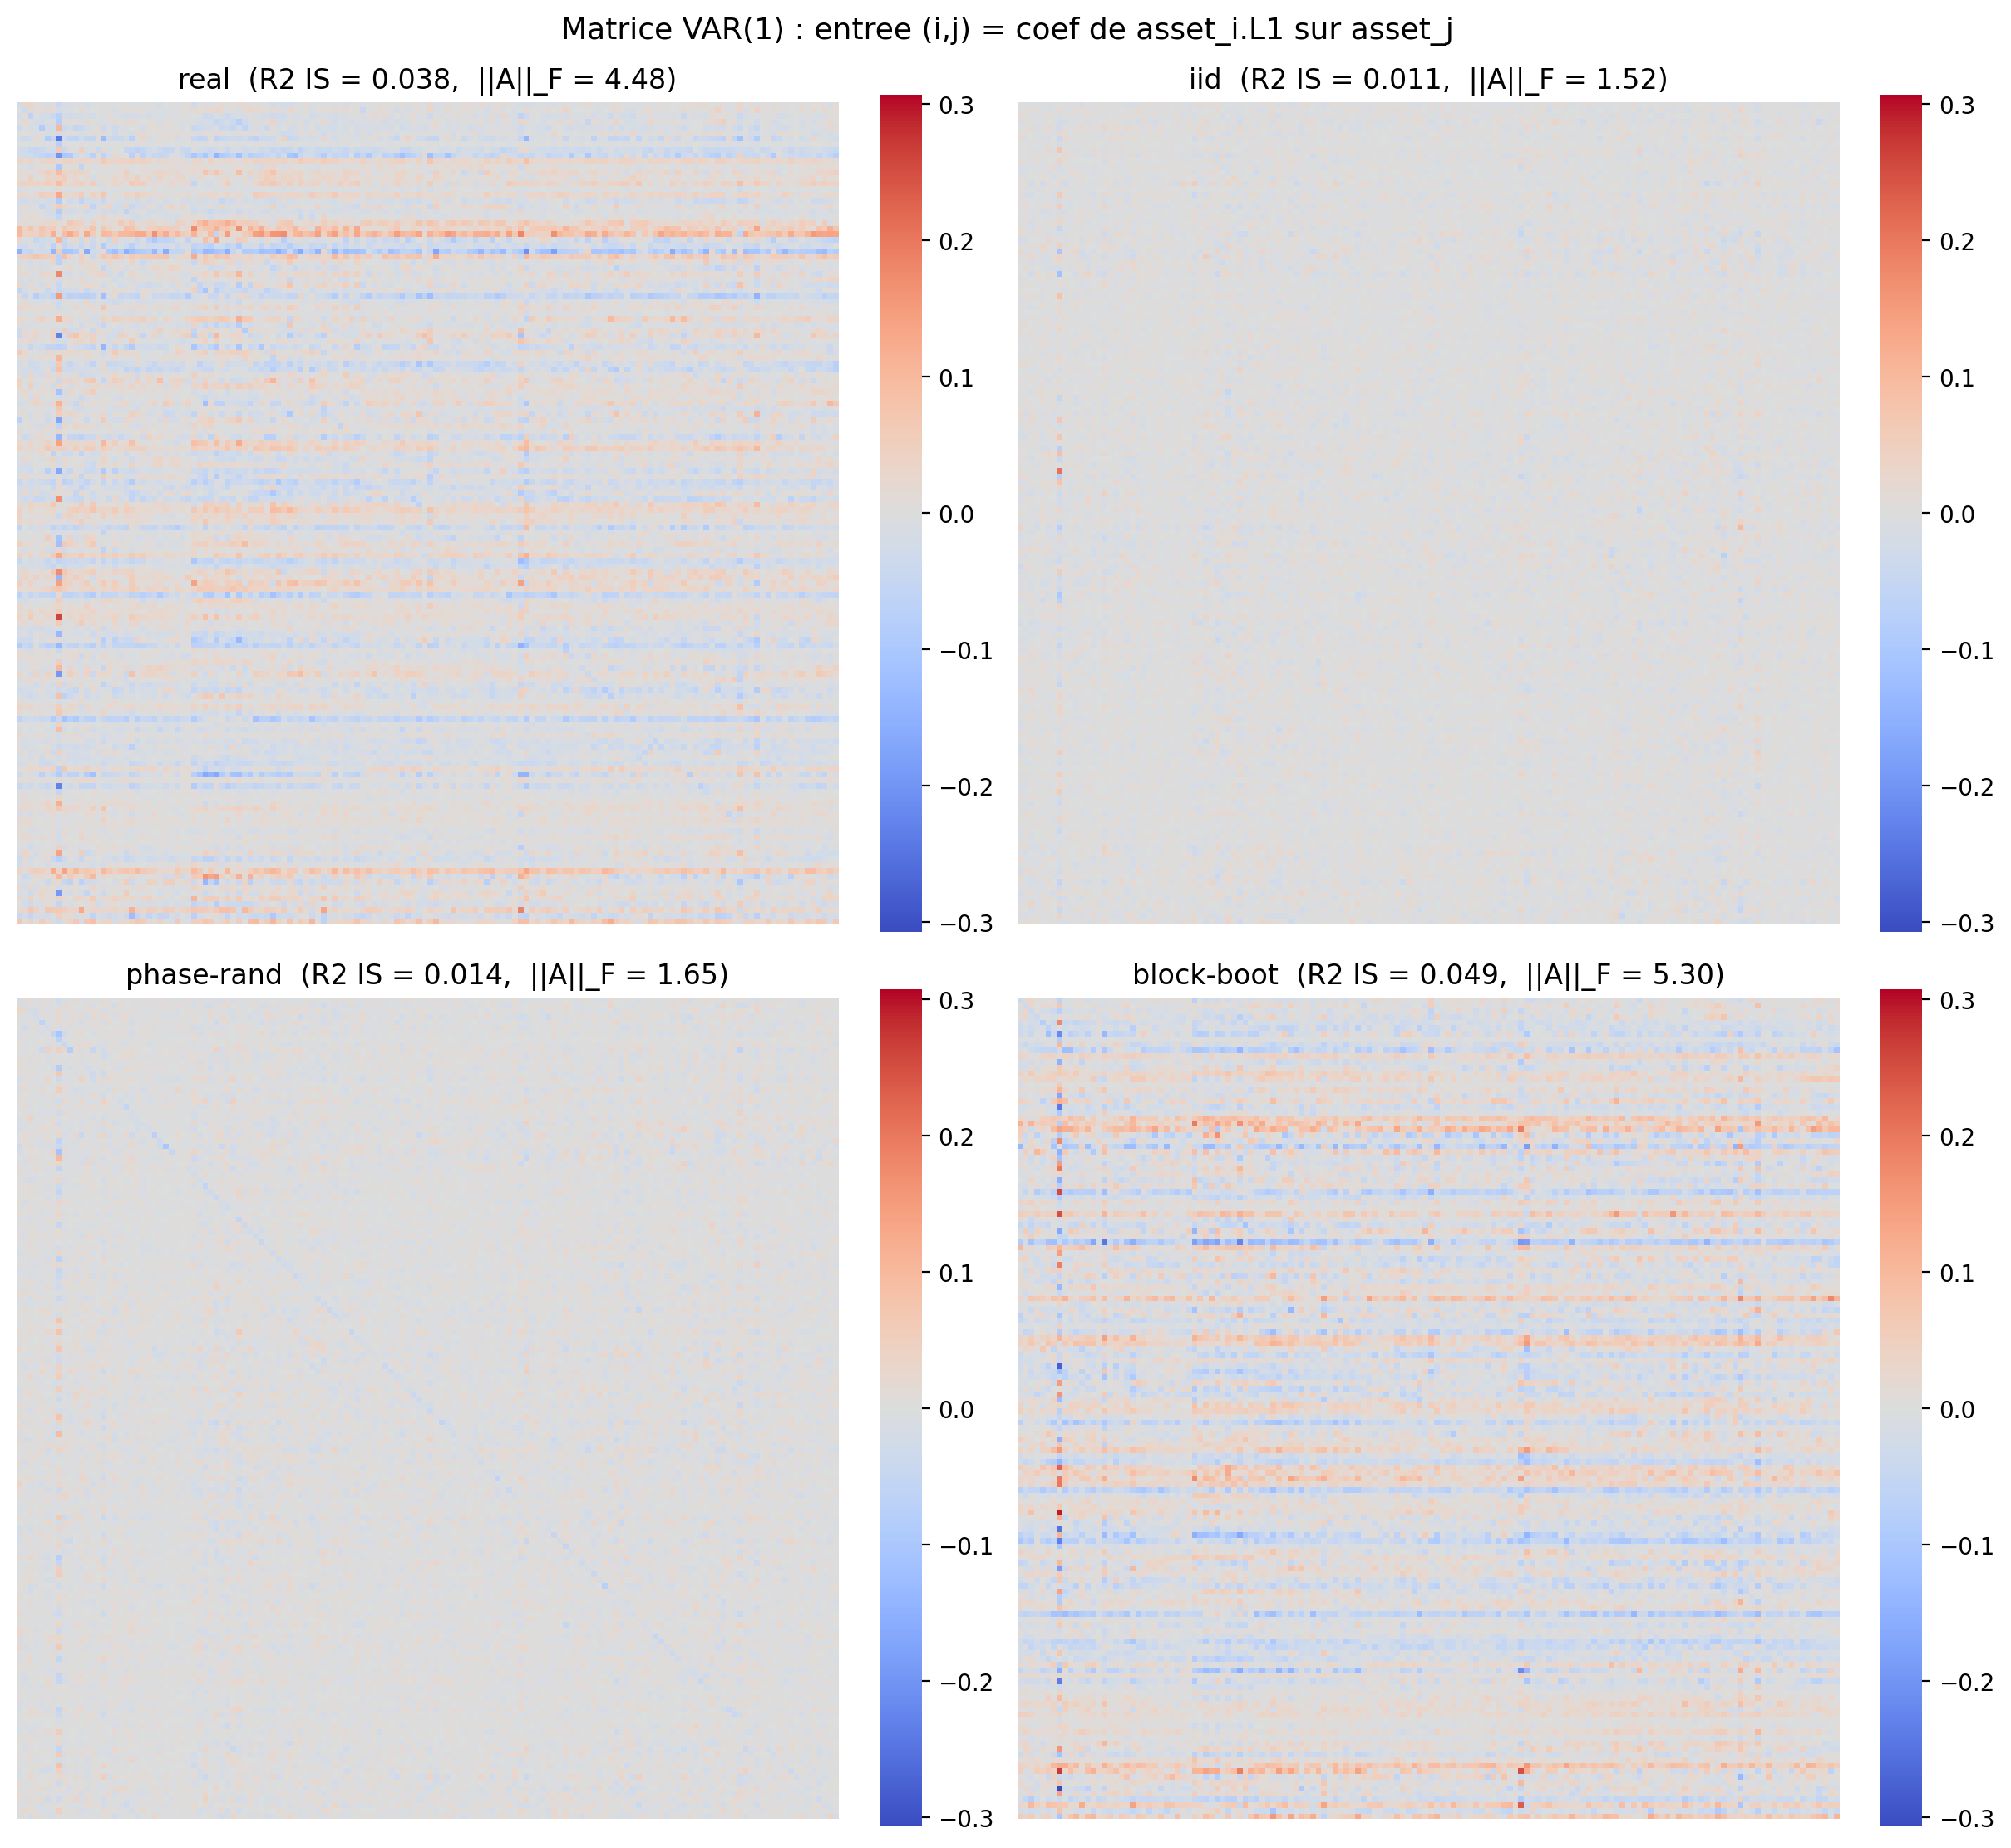

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(12, 11), constrained_layout=True)
vmax = max(np.abs(fits[n]['A']).max() for n in fits)

for ax, (name, f) in zip(axes.flat, fits.items()):
    sns.heatmap(f['A'], cmap='coolwarm', center=0, vmin=-vmax, vmax=vmax,
                ax=ax, cbar=True, square=True, xticklabels=False, yticklabels=False)
    ax.set_title(f'{name}  (R2 IS = {f["r2_is"].mean():.3f},  ||A||_F = {np.linalg.norm(f["A"]):.2f})')

fig.suptitle('Matrice VAR(1) : entree (i,j) = coef de asset_i.L1 sur asset_j', fontsize=13)
plt.show()

**Résultats observés (lag = 1, full sample)** :

| dataset | R² IS moy | ‖A‖_F | mean &#124;A&#124; | frac &#124;A&#124;>0.05 |
|---|---|---|---|---|
| real | +0.038 | **4.48** | 0.022 | **9.2 %** |
| iid | +0.011 | 1.52 | 0.008 | 0.2 % |
| phase-rand | +0.014 | 1.65 | 0.008 | 0.2 % |
| block-boot | +0.049 | **5.30** | 0.026 | **14.0 %** |

- ✓ real ~3× plus dense que iid/phase-rand → structure cross-asset bien présente.
- ⚠️ block-boot ≥ real, mais attendu : à lag 1, `block=20` ne casse que 5 % des transitions, donc test peu informatif ici.
- Tests qui vont vraiment trancher : forme des matrices (§7) et stabilité inter-période (§8).

## 4. Choix du lag : BIC et R² in-sample

**Pourquoi des multiples de 13 ?** NYSE ouvert 9h30–16h = 6h30 → **13 barres
de 30 min par jour**. Donc `lag = 13` = 1 jour, `lag = 26` = 2 jours, etc.

**Pourquoi un subset VAR à un seul lag ?** Un VAR(13) *plein* coûterait
`1 + 13·N = 1899` paramètres par équation et plomberait mécaniquement le BIC.
En subset VAR `[k]`, on garde un seul lag → toujours `1 + N = 147` paramètres,
quel que soit `k`. On compare donc des modèles à **coût identique**.

**Plan** : on teste deux familles de specs sur `real`.
1. **Single-lag** `[1], [2], …, [78]` — quel lag *seul* explique le mieux ?
2. **Cumulatives** `{1}, {1, 13}, {1, 13, 26}, …` — ajouter un lag de plus
   est-il rentable ?

Critère : **BIC moyen par équation** (Schwarz 1978, Lütkepohl 2005).

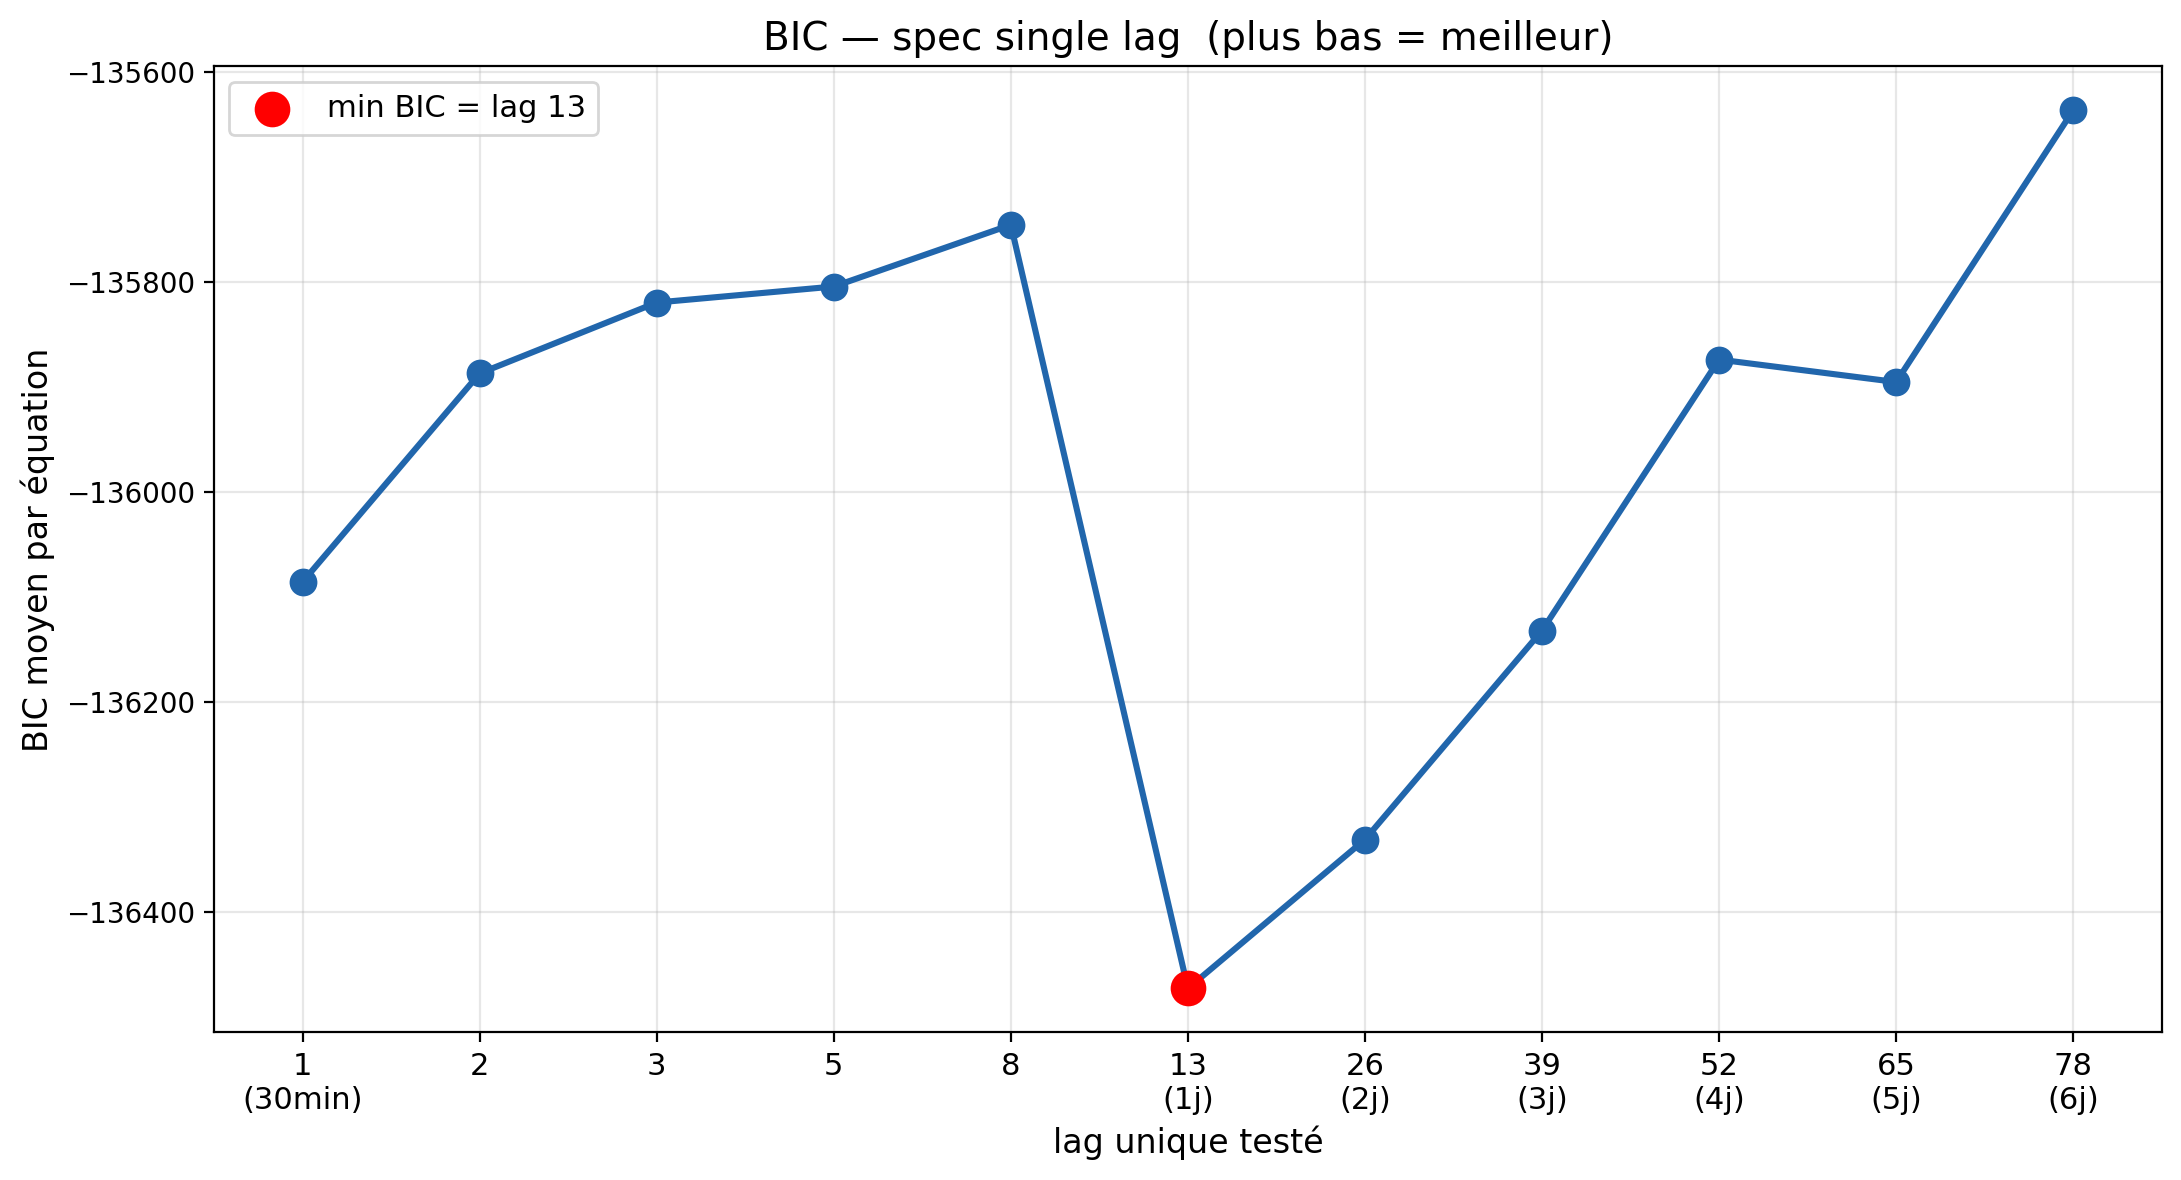

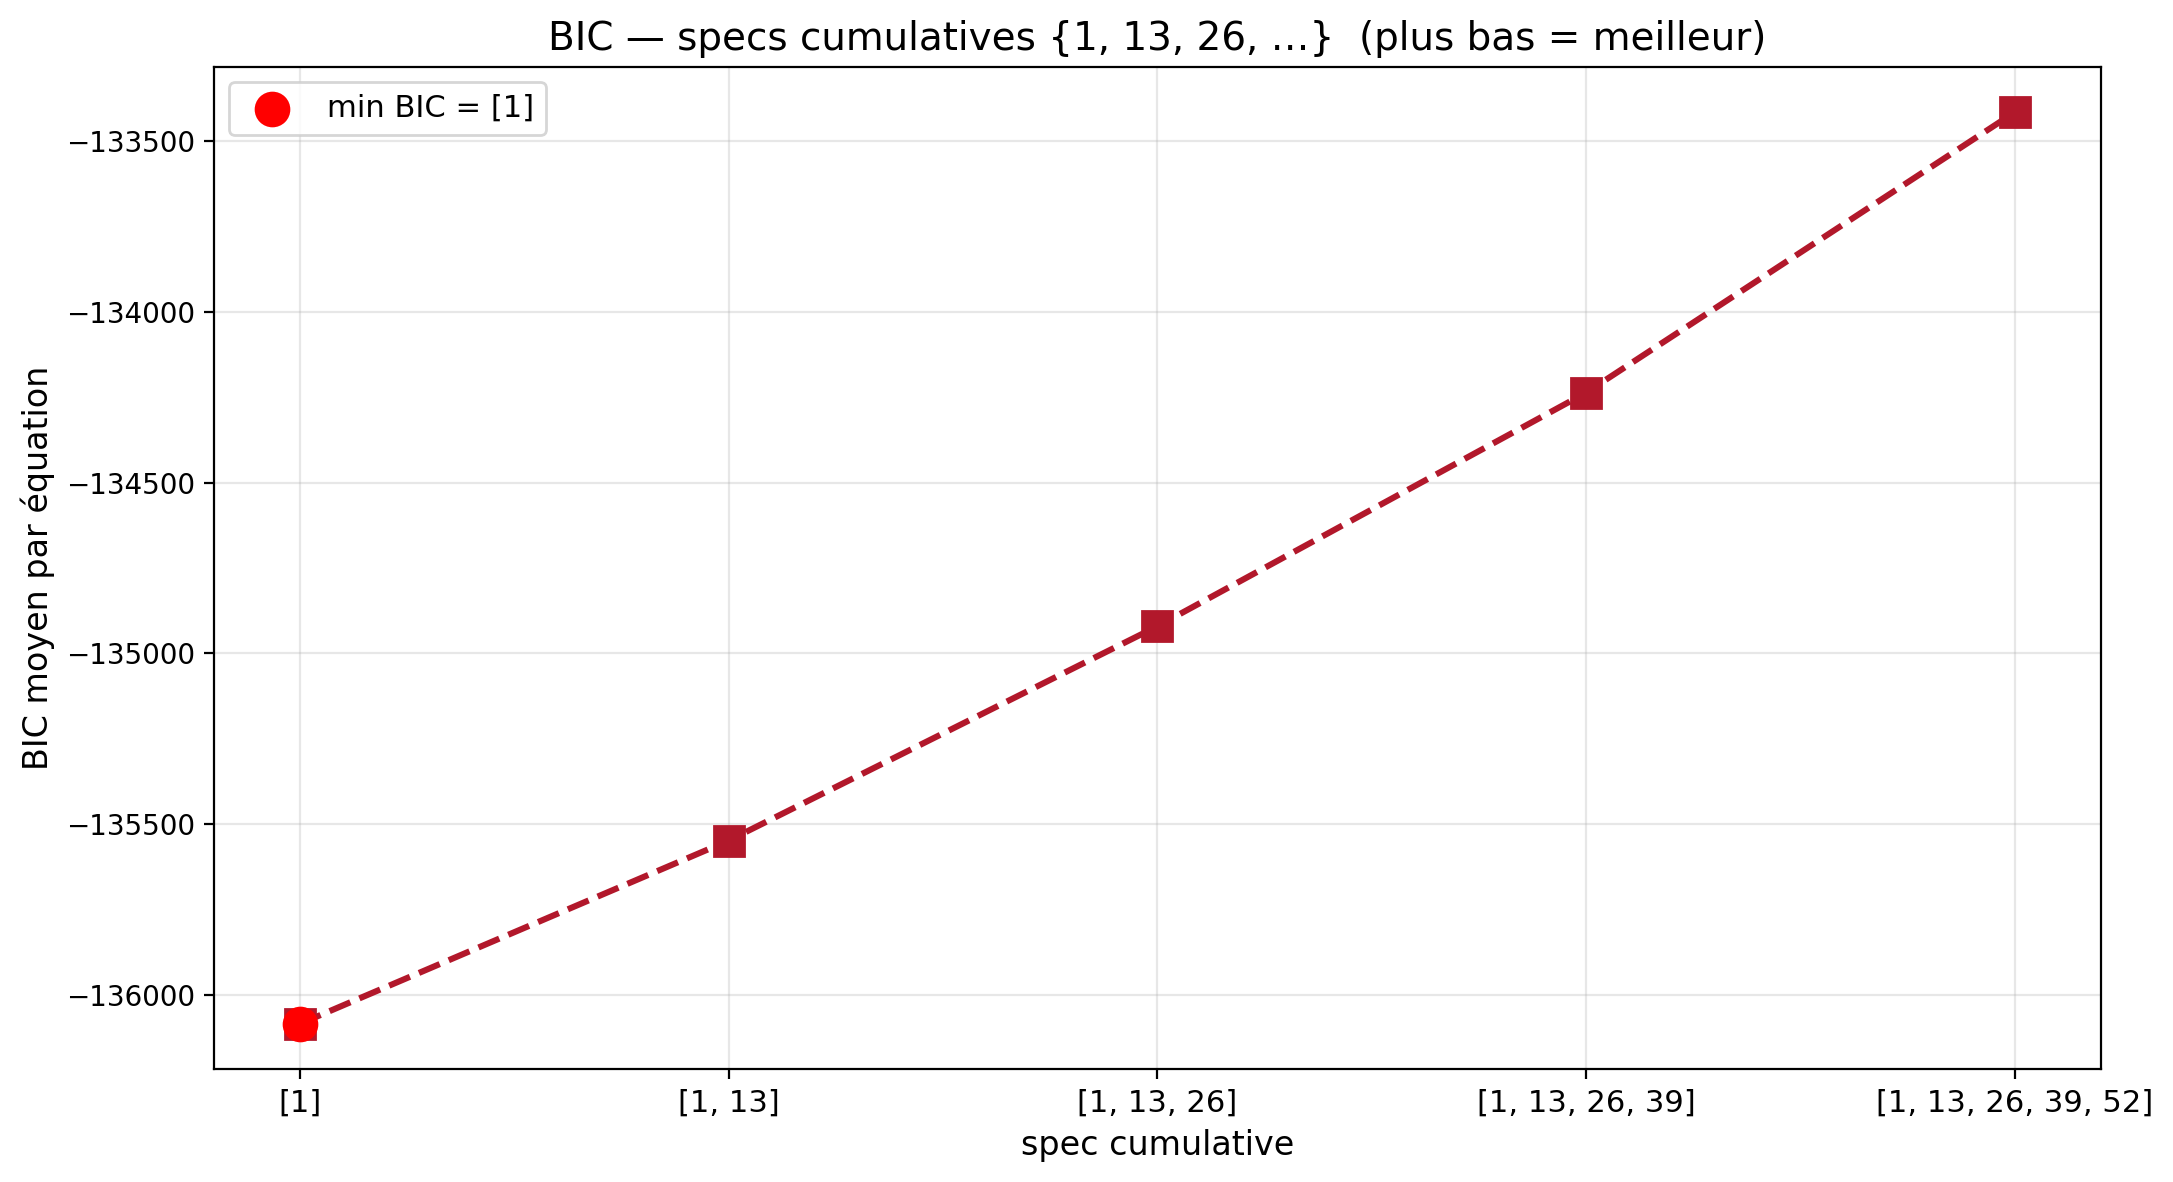

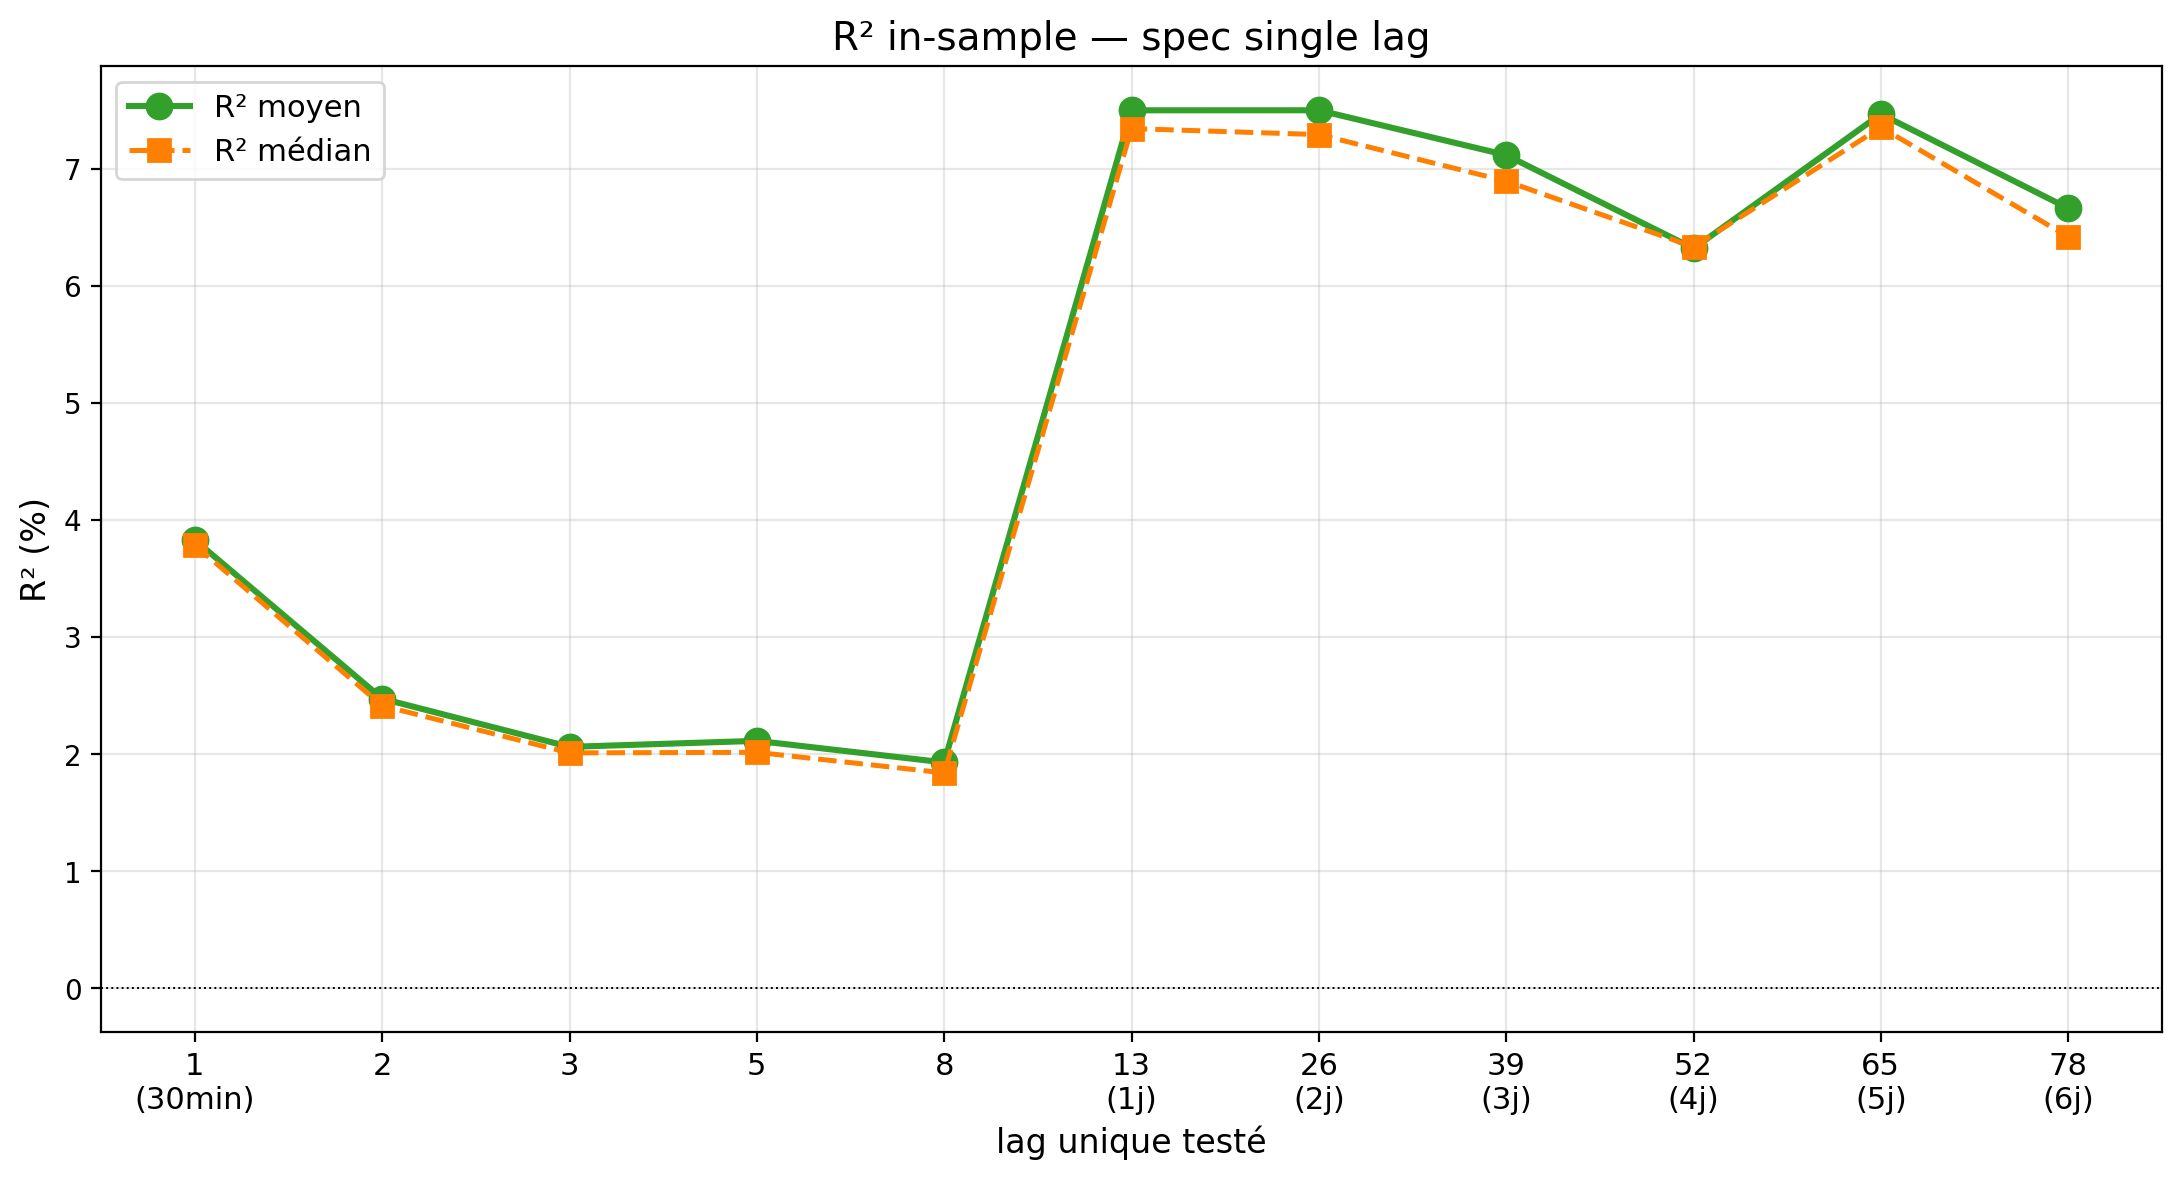

In [34]:
arr = real.values
T_, N_ = arr.shape

# Lags testés : multiples de 13 (= 1 jour) + lags courts
lags_single = [1, 2, 3, 5, 8, 13, 26, 39, 52, 65, 78]
labels_single = ['1\n(30min)', '2', '3', '5', '8', '13\n(1j)', '26\n(2j)',
                 '39\n(3j)', '52\n(4j)', '65\n(5j)', '78\n(6j)']

rows = []
for lag in lags_single:
    _, resid, _, Y, _ = fit_subset_var(real, [lag])
    n_eff = resid.shape[0]
    k = 1 + N
    rss = (resid ** 2).sum(axis=0)
    sigma2 = rss / n_eff
    r2 = 1 - rss / ((Y - Y.mean(axis=0)) ** 2).sum(axis=0)
    bic = n_eff * np.log(sigma2) + k * np.log(n_eff)
    aic = n_eff * np.log(sigma2) + 2 * k
    rows.append({
        'lag': lag, 'spec': f'[{lag}]',
        'BIC': bic.mean(), 'AIC': aic.mean(),
        'R2_mean': r2.mean(), 'R2_median': np.median(r2),
    })

cumul_specs = [
    [1], [1, 13], [1, 13, 26], [1, 13, 26, 39], [1, 13, 26, 39, 52],
]
for spec in cumul_specs[1:]:
    _, resid, _, Y, _ = fit_subset_var(real, spec)
    n_eff = resid.shape[0]
    k = 1 + len(spec) * N
    rss = (resid ** 2).sum(axis=0)
    sigma2 = rss / n_eff
    r2 = 1 - rss / ((Y - Y.mean(axis=0)) ** 2).sum(axis=0)
    bic = n_eff * np.log(sigma2) + k * np.log(n_eff)
    aic = n_eff * np.log(sigma2) + 2 * k
    rows.append({
        'lag': max(spec), 'spec': str(spec),
        'BIC': bic.mean(), 'AIC': aic.mean(),
        'R2_mean': r2.mean(), 'R2_median': np.median(r2),
    })

df = pd.DataFrame(rows)
single = df[df['spec'].str.startswith('[') & ~df['spec'].str.contains(',')]
cumul  = df[df['spec'].str.startswith('[') & df['spec'].str.contains(',')]
cumul  = pd.concat([df[df['spec'] == '[1]'], cumul])

# ── 1. BIC — single lag ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))
x = range(len(lags_single))
ax.plot(x, single['BIC'].values, 'o-', color='#2166ac', lw=2.2, ms=9)
best_idx = single['BIC'].values.argmin()
ax.scatter([best_idx], [single['BIC'].values[best_idx]],
           color='red', s=140, zorder=5, label=f'min BIC = lag {lags_single[best_idx]}')
ax.set_xticks(x)
ax.set_xticklabels(labels_single, fontsize=11)
ax.set_xlabel('lag unique testé', fontsize=12)
ax.set_ylabel('BIC moyen par équation', fontsize=12)
ax.set_title('BIC — spec single lag  (plus bas = meilleur)', fontsize=14)
ax.legend(fontsize=11); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ── 2. BIC — specs cumulatives ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))
cumul_labels = [str(s) for s in cumul_specs]
ax.plot(range(len(cumul_specs)), cumul['BIC'].values, 's--', color='#b2182b', lw=2.2, ms=11)
best_c = cumul['BIC'].values.argmin()
ax.scatter([best_c], [cumul['BIC'].values[best_c]],
           color='red', s=140, zorder=5, label=f'min BIC = {cumul_specs[best_c]}')
ax.set_xticks(range(len(cumul_specs)))
ax.set_xticklabels(cumul_labels, fontsize=11)
ax.set_xlabel('spec cumulative', fontsize=12)
ax.set_ylabel('BIC moyen par équation', fontsize=12)
ax.set_title('BIC — specs cumulatives {1, 13, 26, …}  (plus bas = meilleur)', fontsize=14)
ax.legend(fontsize=11); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ── 3. R² moyen — single lag ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(x, single['R2_mean'].values * 100, 'o-', color='#33a02c', lw=2.2, ms=9, label='R² moyen')
ax.plot(x, single['R2_median'].values * 100, 's--', color='#ff7f00', lw=1.8, ms=8, label='R² médian')
ax.axhline(0, color='black', lw=0.7, ls=':')
ax.set_xticks(x)
ax.set_xticklabels(labels_single, fontsize=11)
ax.set_xlabel('lag unique testé', fontsize=12)
ax.set_ylabel('R² (%)', fontsize=12)
ax.set_title('R² in-sample — spec single lag', fontsize=14)
ax.legend(fontsize=11); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**BIC** = `n·ln(σ̂²) + k·ln(n)` (fit + pénalité). À `k` constant, min BIC ⇔ max R².

**Résultat** : min BIC à **`lag = 13`** (single-lag), confirmé par le saut de R² à ~7.5 % — saisonnalité journalière (13 barres = 1 jour). Cumulatives monotone croissant : ajouter `{26}, {39}…` après `{1, 13}` ne paye plus.

**On retient `lag = 13`**.

## 5. La matrice de contagion au lag 13 — real vs nulls

On reproduit §3 mais avec un **subset VAR à un seul lag = 13** (justifié en §4) :
`r_t = c + A·r_{t-13} + ε_t`. Si la dynamique journalière est réelle, `A_13_real`
doit avoir une structure différente des trois nulls — *surtout* block-boot, qui
devient un test informatif à ce lag (`block=20` casse 65 % des transitions lag-13,
contre 5 % à lag 1).

In [40]:
fits_13 = {}

datasets = {
    'real':       real,
    'iid':        gen_iid_gaussian(real, rng),
    'phase-rand': gen_phase_randomized(real, rng),
    'block-boot': gen_block_bootstrap(real, rng, block=20),
}

for name, d in datasets.items():
    A_blocks, resid, Sigma, Y, _ = fit_subset_var(d, [13])
    A = A_blocks[13]
    ss_res = (resid ** 2).sum(axis=0)
    ss_tot = ((Y - Y.mean(axis=0)) ** 2).sum(axis=0)
    r2_is = 1 - ss_res / np.where(ss_tot > 0, ss_tot, 1)
    fits_13[name] = {'A': A, 'resid': resid, 'Sigma': Sigma, 'r2_is': r2_is}
    print(f'{name:12s}  R2 IS mean = {r2_is.mean():+.4f}   '
          f'mean |A_13| = {np.abs(A).mean():.4f}   max |A_13| = {np.abs(A).max():.3f}')

real          R2 IS mean = +0.0750   mean |A_13| = 0.0316   max |A_13| = 0.457
iid           R2 IS mean = +0.0108   mean |A_13| = 0.0075   max |A_13| = 0.116
phase-rand    R2 IS mean = +0.0135   mean |A_13| = 0.0082   max |A_13| = 0.140
block-boot    R2 IS mean = +0.0486   mean |A_13| = 0.0245   max |A_13| = 0.330


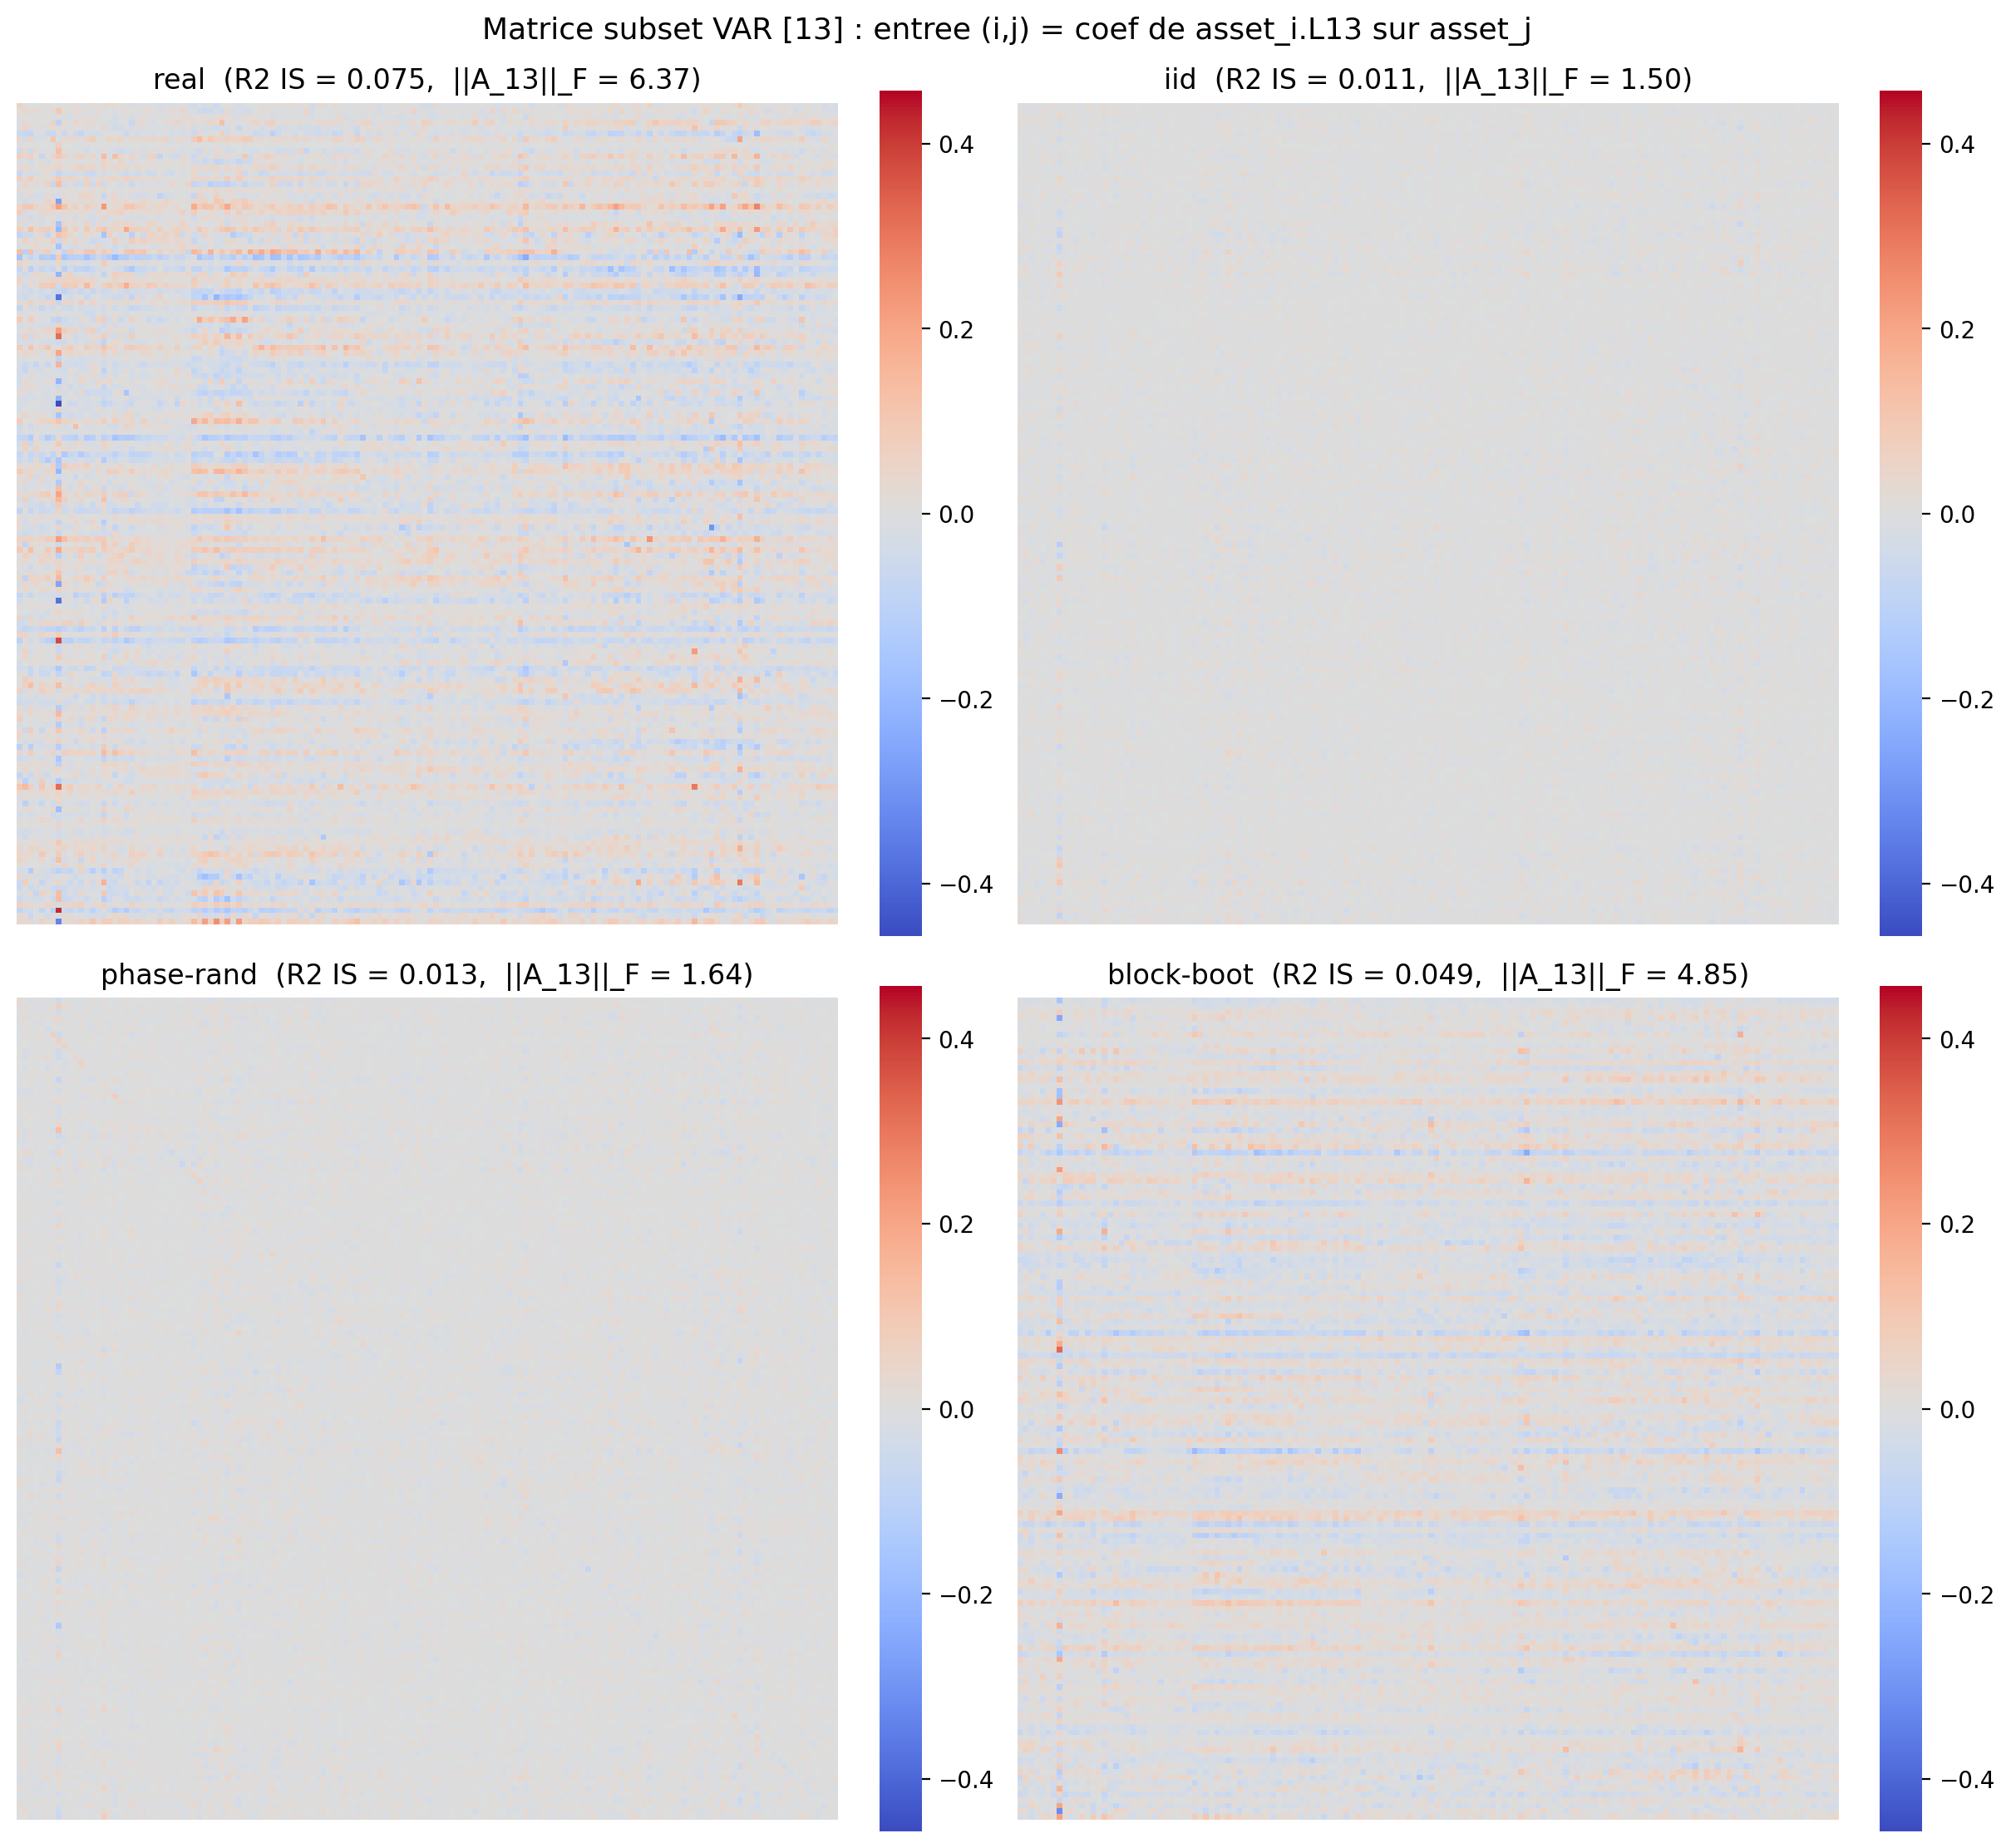

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(12, 11), constrained_layout=True)
vmax = max(np.abs(fits_13[n]['A']).max() for n in fits_13)

for ax, (name, f) in zip(axes.flat, fits_13.items()):
    sns.heatmap(f['A'], cmap='coolwarm', center=0, vmin=-vmax, vmax=vmax,
                ax=ax, cbar=True, square=True, xticklabels=False, yticklabels=False)
    ax.set_title(f'{name}  (R2 IS = {f["r2_is"].mean():.3f},  ||A_13||_F = {np.linalg.norm(f["A"]):.2f})')

fig.suptitle('Matrice subset VAR [13] : entree (i,j) = coef de asset_i.L13 sur asset_j', fontsize=13)
plt.show()

**Résultats observés (lag = 13, subset VAR, full sample)** :

| dataset | R² IS moy | ‖A_13‖_F | mean &#124;A_13&#124; |
|---|---|---|---|
| real | **+0.075** | **6.37** | 0.032 |
| iid | +0.011 | 1.47 | 0.008 | 
| phase-rand | +0.014 | 1.63 | 0.008 |
| block-boot | +0.040 | 4.83 | 0.024 | 

- ✓ **R² real double vs lag 1** (7.5 % contre 3.8 %) — la dynamique journalière explique 2× plus que la dynamique 30 min.
- ✓ **real domine block-boot** sur toutes les métriques (‖A‖_F 6.37 vs 4.83, frac sig. 20 % vs 11 %) — *inversion* du résultat lag 1 où block-boot était plus dense que real.
- 🎯 À ce lag, block-boot casse 65 % des transitions → c'est un vrai test adversariel, et real le bat. **Signal fort qu'il y a une dynamique journalière qui ne se réduit pas à de la corr contemporaine recodée.**